## PyMC v6 & PyTensor v3: ecosystem updates

PyMC has been under steady development since the early 2010s.
To mark the new major releases of PyMC v6 and PyTensor v3,
we want to highlight the developments across the PyMC ecosystem
(and its close cousin, the ArviZ ecosystem) that we're most excited about.

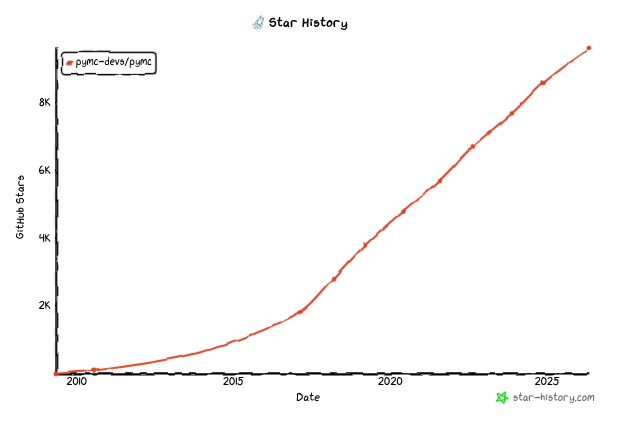

### What's new in PyMC v6
PyMC v6 starts faster, runs better, and can finally be **pip install**ed. No extra system setup required.

Under the hood, we've streamlined the computational backend (PyTensor) and switched the default computational backend to Numba,
while keeping it easy to opt into others on demand (C, JAX, MLX, …).

For inference, PyMC now uses the nutpie NUTS sampler by default when installed, and pymc-extras provides easy access to Pathfinder and DADVI variational inference.

On the modeling side, the new pymc.dims module makes it natural to define dimension-aware models,
while sister packages add automatic marginalization, a clean state-space model API, and Bayesian Additive Regression Trees (BART).

The surrounding ecosystem has grown and matured too.
ArviZ has entered version 1.0, with a more modular and flexible design to support the rest of the Bayesian workflow.
Tools like PyMC-BART and PreliZ are more tightly integrated,
and new additions like Kulprit bring automated variable selection into the workflow.


### At a glance
* Performance & usability: Numba as the new default backend, simple backend switching, clean pip install
* Inference: nutpie NUTS sampler, Pathfinder and DADVI variational inference
* Modeling: named dimensions (pymc.dims), automatic marginalization, state-space models, BART,
* Building blocks: automatic logp, wrap_jax
* Workflow: ArviZ 1.0, variable selection with Kulprit, prior elicitation with PreliZ

## Performance

PyMC hasn't always been a breeze to use. It's written in Python, and its backend
(Theano, and its successor PyTensor) had accrued some weight over the years.

A lot of effort was devoted to speeding up all stages of work:
from import times, to model compilation and sampling runtime.

### Numba is the new default backend

Historically, PyMC compiled model functions to **C**, with some support for CUDA. In v6 we
switch the default linker to **Numba**. For most CPU workloads Numba matches or beats C,
while being far easier to maintain and extend.
It also unlocks a few things the old C path always struggled with:

- **Native advanced indexing** — The kind of operations that show up all the time in hierarchical models.
  C-support for indexing operations has always been a source of friction.
  Numba provides native support to (almost) all cases of advanced indexing with noticeably better performance.
  Ongoing work to combine mathematical and indexing operations into fused kernels should yield further improvements.
- **LAPACK bindings for linear algebra** — `cholesky`, `solve`, `eigh`, and friends aren't bottlenecked by Python.
- **Fast `scan`** — historically the slowest piece of the C backend, `scan` has been rewired for Numba
  and is now far closer to looping in a low-level language (with autodiff).
  This should greatly aid time-series and other models with recursive structures.
- **Native sparse support** — PyTensor supports sparse tensors operations in Numba.
  Useful for spatial models (ICAR) and State-Space models, as well as inference routines like INLA.


A knock-on win: **PyMC is finally `pip install`-safe.** The old C backend needed a working
BLAS install *and* a C++ compiler — pip wheels bring neither. The first-time experience on a
clean machine used to greet you with a prominent "PyTensor could not link to a BLAS
installation" warning and degraded performance (or worse if a compiler couldn't be detected).
Conda/mamba was the only reliable path.

### One-liner backend selection with `backend=`

You can pass `backend=` directly to **every** sampling entry point — `pm.sample`,
`pm.sample_prior_predictive`, `pm.sample_posterior_predictive`, the deterministic-
recomputation helpers, `pm.fit` (variational), `pm.sample_smc`, and the `log_density` /
`logp` utilities.

Accepted values include `"numba"`, `"c"`, and `"jax"`.

You don't have to pass it at all — `backend="numba"` is the default, so `pm.sample(...)`
already uses Numba. You only need the keyword when you want something else.

**Availability:** `Numba` and C ship with PyMC — though C needs both a C++ compiler
and a working BLAS install at runtime to be usable at all. JAX has to be installed separately.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Silence JAX's "os.fork() was called" RuntimeWarning emitted by worker startup.
os.environ["PYTHONWARNINGS"] = "ignore:os.fork:RuntimeWarning"
warnings.filterwarnings("ignore", message=r"os\.fork\(\) was called.*", category=RuntimeWarning)

In [2]:
import pymc as pm

rng = np.random.default_rng(0)
y_obs = rng.normal(1.0, 0.5, size=50)

with pm.Model() as simple_model:
    mu = pm.Normal("mu")
    sigma = pm.HalfNormal("sigma")
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)

In [3]:
with simple_model:
    idata_numba = pm.sample(backend="numba", quiet=True)
    idata_jax = pm.sample(backend="jax", quiet=True)
    idata_c = pm.sample(backend="c", quiet=True)

All should arrive at the same place, if not at the same time.

In [4]:
pd.concat([
    pm.stats.summary(idata_numba, var_names=["mu"], kind="stats").rename({"mu": "mu (numba)"}),
    pm.stats.summary(idata_jax, var_names=["mu"], kind="stats").rename({"mu": "mu (jax)"}),
    pm.stats.summary(idata_c, var_names=["mu"], kind="stats").rename({"mu": "mu (c)"}),
])

,mean,sd,eti89_lb,eti89_ub
mu (numba),1.1,0.066,0.95,1.2
mu (jax),1.1,0.067,0.96,1.2
mu (c),1.1,0.066,0.96,1.2


## Inference

### Nutpie: the new default NUTS sampler

PyMC has historically latched onto Stan's implementation of NUTS,
borrowing its code almost line-by-line.
It was time to contribute something back, and that something is
[**nutpie**](https://pymc-devs.github.io/nutpie/).

You can easily install pymc and nutpie together as:

```bash
pip install pymc[nutpie]
```

Once installed, nutpie becomes the **default** NUTS in PyMC.

Three things make it a step change over what we had before:

- **Faster adaptation.** Nutpie often gets away with ~400 tuning draws where the old default
  conservatively used 1000, and after tuning it takes fewer leapfrog steps per draw, with no
  loss of accuracy. If you want to dive into the nitty-gritty, check out [Seyboldt, Carlson, & Carpenter (2026)](https://arxiv.org/abs/2603.18845).
- **Low-rank mass-matrix adaptation.** For posteriors with strongly correlated parameters, the
  diagonal mass matrix used by most HMC implementations is a poor fit. Nutpie offers a low-rank
  extension of the diagonal that can dramatically reduce the number of gradient evaluations per
  effective draw on funnels, regressions with collinear predictors, and similar shapes.
- **Implemented in rust** with direct integration with Numba and JAX backends.

An experimental **normalizing-flow adaptation** is also available for really difficult
posteriors; see the [nutpie docs](https://pymc-devs.github.io/nutpie/nf-adapt.html).

To be sure not to miss the train, set `nuts_sampler="nutpie"` explicitly.

In [5]:
with simple_model:
    idata_nutpie = pm.sample(nuts_sampler="nutpie")

NUTS[nutpie]: [mu, sigma]


Output()

In [6]:
pm.stats.summary(idata_nutpie)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,1.058,0.065,0.95,1.2,3826,2942,1.00,0.0011,0.00074
sigma,0.472,0.049,0.4,0.56,3625,2714,1.00,0.00083,0.00068


A classic nasty posterior: a simple linear regression where the covariate sits far from zero,
making the intercept and slope strongly anti-correlated in the likelihood.

In [7]:
rng_corr = np.random.default_rng(1)
N = 200
x_far = rng_corr.normal(1000.0, 1.0, size=N)
y_far = 2.0 + 3.0 * x_far + rng_corr.normal(0.0, 1.0, size=N)

with pm.Model() as regression_far:
    a = pm.Normal("a", 0.0, 10)
    b = pm.Normal("b", 0.0, 10.0)
    sigma = pm.HalfNormal("sigma", 1.0)
    pm.Normal("y", mu=a + b * x_far, sigma=sigma, observed=y_far)

In [8]:
with regression_far:
    idata_diag = pm.sample(nuts={"adaptation": "diag"}, quiet=True)

pm.stats.summary(idata_diag, var_names=["a", "b"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,-0,9.9,-17,15,326,445,1.02,0.54,0.36
b,3.002,0.0099,3,3,325,444,1.02,0.00054,0.00036


The low rank adaptation fares much better than the default diagonal mass matrix adaptation.

In [9]:
with regression_far:
    idata_lr = pm.sample(nuts={"adaptation": "low_rank"}, quiet=True)

pm.stats.summary(idata_lr, var_names=["a", "b"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,-0.9,9.9,-17,15,5904,3169,1.00,0.13,0.089
b,3.0028,0.0099,3,3,5903,3168,1.00,0.00013,8.9e-05


### Variational inference (pymc-extras): Pathfinder & DADVI

Pymc-extras ships with two modern Variational Inference solutions.

**Pathfinder** Pathfinder is a parallel quasi-Newton variational approximation:
it runs L-BFGS from multiple starting points and combines the resulting trajectories using Pareto-smoothed importance sampling.
It's fast, parallelizable, and useful both as a NUTS warm-start and as a standalone approximation. See [Zhang et al. (2022)](https://arxiv.org/abs/2108.03782).

In [10]:
from pymc_extras import fit_pathfinder

with simple_model:
    idata_pf = fit_pathfinder(display_summary=False)

Output()

**DADVI** — *Deterministic* ADVI.
nstead of stochastic optimization of the ELBO, it draws a fixed Monte Carlo sample upfront
and hands the resulting deterministic objective to a second-order optimizer.
Three things fall out of this: convergence is unambiguous (no more "is the ELBO done bouncing around?"),
off-the-shelf optimizers like L-BFGS work directly, and DADVI supports linear-response covariance corrections
that fix the variance underestimation that mean-field ADVI is famous for. See [Giordano, Ingram & Broderick (2024)](https://jmlr.org/papers/volume25/23-1015/23-1015.pdf).

In [11]:
from pymc_extras.inference import fit_dadvi

with simple_model:
    idata_dadvi = fit_dadvi()

Output()

In [12]:
pd.concat([
    pm.stats.summary(idata_pf, var_names=["mu"], kind="stats").rename({"mu": "mu (pathfinder)"}),
    pm.stats.summary(idata_dadvi, var_names=["mu"], kind="stats").rename({"mu": "mu (dadvi)"}),
])

,mean,sd,eti89_lb,eti89_ub
mu (pathfinder),1.1,0.065,0.96,1.2
mu (dadvi),1.1,0.071,0.94,1.2


## Modelling

## Named dims with `pymc.dims`

PyMC's `dims=` argument has existed since 2020 — you've probably used it to attach string
names to axes of a random variable. In v6 it grows up. The new `pymc.dims` module (backed by
PyTensor's XTensor) lets you write **entire models** against named dimensions, with automatic
broadcasting, no more `[:, None, :]` gymnastics, and no more guessing which axis is which.

A compact example (adapted from the [pymc.dims core
notebook](https://www.pymc.io/projects/docs/en/latest/learn/core_notebooks/dims_module.html) — see it for a full tour).

In [13]:
import pymc.dims as pmd

coords = {
    "participant": range(5),
    "trial": range(20),
    "item": range(3),
}
observed_response_np = np.ones((5, 20), dtype=int)

with pm.Model(coords=coords) as dmodel:
    observed_response = pmd.Data(
        "observed_response",
        observed_response_np,
        dims=("participant", "trial"),
    )

    participant_preference = pmd.ZeroSumNormal(
        "participant_preference",
        core_dims="item",
        dims=("participant", "item"),
    )
    time_effects = pmd.Normal("time_effects", dims=("item", "trial"))

    trial_preference = pmd.Deterministic(
        "trial_preference",
        participant_preference + time_effects,
    )

    response = pmd.Categorical(
        "response",
        p=pmd.math.softmax(trial_preference, dim="item"),
        core_dims="item",
        observed=observed_response,
    )

Notice what is **not** in that model: no `None`-indexing to create new axes, no right-align
conventions to keep track of, no numerical `axis` argument.

Also new: the `Model.table()` method renders a compact summary of every variable together
with its expression and dimensions — a much more compact view than the good old `Model.to_graphviz()`.

In [14]:
dmodel.table()

                 Variable  Expression                               Dimensions                           
─────────────────────────────────────────────────────────────────────────────────────────────────────────
      observed_response =  Data                                     participant[5] × trial[20]           
                                                                                                         
 participant_preference ~  ZeroSumNormal(<constant>, <constant>)    participant[5] × item[3]             
           time_effects ~  Normal(0, 1)                             item[3] × trial[20]                  
                                                                    Parameter count = 75                 
                                                                                                         
       trial_preference =  f(time_effects, participant_preference)  participant[5] × item[3] × trial[20] 
                                                                                                         
               response ~  Categorical(f(trial_preference))         participant[5] × trial[20]

### Automatic marginalization (pymc-extras)

Discrete latent variables are a pain to sample with gradient-based MCMC.
Traditionally you'd have to sum them out by hand and rewrite your model as a marginal likelihood.
`pymc_extras.marginalize` automates that process.

In [15]:
from pymc_extras import marginalize, recover_marginals

rng_mix = np.random.default_rng(2)
y_mix = rng_mix.normal(loc=np.tile([-2, 2], reps=50))
mix_coords = {"component": ["left", "right"], "obs": range(len(y_mix))}

with pm.Model(coords=mix_coords) as mix_model:
    w = pm.Dirichlet("w", a=np.ones(2))
    mu = pm.Normal("mu", mu=[-3.0, 3.0], dims="component")
    sigma = pm.HalfNormal("sigma", dims="component")
    z = pm.Categorical("z", p=w, dims="obs")
    pm.Normal("y", mu=mu[z], sigma=sigma[z], observed=y_mix, dims="obs")

marginal_model = marginalize(mix_model, ["z"])

with marginal_model:
    idata_mix = pm.sample(quiet=True)

pm.stats.summary(idata_mix, var_names=["w", "mu"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
w[0],0.497,0.056,0.41,0.59,2908,2881,1.00,0.001,0.00075
w[1],0.503,0.056,0.41,0.59,2908,2881,1.00,0.001,0.00075
mu[left],-1.908,0.159,-2.2,-1.6,2617,2678,1.00,0.0031,0.0024
mu[right],1.878,0.174,1.6,2.1,2571,2385,1.00,0.0035,0.003


After sampling the marginalized model, you can still **recover draws for the discrete
latents** with `recover_marginals` — the component assignments for each observation come back
as proper posterior estimates.

In [16]:
with marginal_model:
    idata_mix = recover_marginals(idata_mix)

In [17]:
pm.stats.summary(idata_mix.isel(obs=slice(None, 6)), var_names=["z"], kind="stats")[["mean", "sd"]]

,mean,sd
z[0],0.0043,0.065
z[1],0.99,0.071
z[2],0.0013,0.035
z[3],0.2,0.4
z[4],0.36,0.48
z[5],1,0


### Statespace (pymc-extras)

`pymc_extras.statespace` offers Bayesian statespace models with an increasingly rich high-level API: 
`BayesianETS`, `BayesianSARIMAX`, `BayesianVARMAX`, plus a `structural` package for
composing custom models out of level, trend, seasonal, and cyclical components.

Here we build a simple structural model with trend and seasonality. Some entries are marked as missing `nan` and automatically imputed by the model.

In [18]:
from pymc_extras.statespace.models.structural import (
    FrequencySeasonality,
    LevelTrend,
    MeasurementError,
)

# Synthetic monthly series: trend + annual seasonality + noise
rng = np.random.default_rng(3)
T = 120
dates = pd.date_range("2015-01", periods=T, freq="MS")
t = np.arange(T)
y_true = 10 + rng.normal(0.05, 0.1, size=T) * t + rng.normal(2.0, 0.1, size=T) * np.sin(2 * np.pi * t / 12)
y_ts = rng.normal(y_true, scale=0.3)

# Punch some NaN gaps — the Kalman filter imputes them automatically
y_df = pd.DataFrame({"y": y_ts}, index=dates)
y_df.loc["2018-05":"2019-09", "y"] = np.nan

ss = (
    LevelTrend(order=2, innovations_order=[0, 1])
    + FrequencySeasonality(season_length=12, n=2, name="annual")
    + MeasurementError()
).build()

                                 Model Requirements                                  
                                                                                     
  Variable                 Shape    Constraints                          Dimensions  
 ─────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend      (2,)                              ('state_level_trend',)  
  sigma_level_trend        (1,)     Positive                 ('shock_level_trend',)  
  params_annual            (4,)                                   ('state_annual',)  
  sigma_annual             ()       Positive                                   None  
  sigma_MeasurementError   ()       Positive                                   None  
  P0                       (6, 6)   Positive semi-definite   ('state', 'state_aux')  
                                                                                     
 These parameters should be assigned priors inside a PyMC model block before calling 
                         the build_statespace_graph method.                          

In [19]:
with pm.Model(coords=ss.coords) as sts_model:
    pm.Normal("initial_level_trend", mu=[10, 0], sigma=[5, 1], dims=["state_level_trend"])
    pm.HalfNormal("sigma_level_trend", dims=["shock_level_trend"])

    pm.Normal("params_annual", sigma=2, dims=["state_annual"])
    pm.HalfNormal("sigma_annual")

    pm.HalfNormal("sigma_MeasurementError")
    P0_diag = pm.HalfNormal("P0_diag", shape=(ss.k_states,))

    pm.Deterministic("P0", pm.math.diag(P0_diag), dims=("state", "state_aux"))
    ss.build_statespace_graph(data=y_df)

    idata_sts = pm.sample(progressbar="combined")

/home/ricardo/Documents/pymc-extras-worktree3/pymc_extras/statespace/utils/data_tools.py:179: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
NUTS[nutpie]: [initial_level_trend, sigma_level_trend, params_annual, sigma_annual, sigma_MeasurementError, P0_diag]


Output()

After sampling there are handy tools to extract predictions, structural decomposition and scenario forecast (not shown).

In [20]:
smoothed = ss.sample_conditional_posterior(idata_sts, progressbar=False)
components = ss.extract_components_from_idata(smoothed)

/home/ricardo/Documents/pymc-extras-worktree3/pymc_extras/statespace/utils/data_tools.py:179: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]
Variables filtered_posterior_observed, predicted_posterior_observed, smoothed_posterior_observed do not contain all hidden states (their last dimension is not 6). They will not be present in the modified idata.


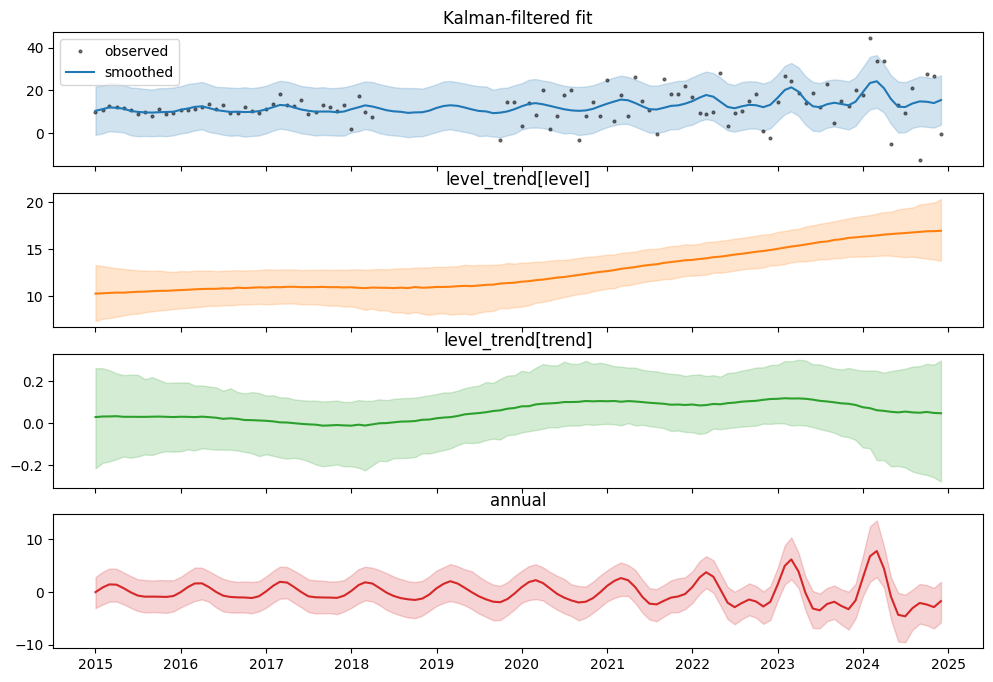

In [31]:
obs = smoothed["smoothed_posterior_observed"].sel(observed_state="data")
sp = components["smoothed_posterior"]
comp_names = list(components.coords["state"].values)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# Smoothed observed fit — imputes over NaN gaps
axes[0].plot(dates, y_df["y"], "k.", ms=4, alpha=0.5, label="observed")
axes[0].plot(dates, obs.mean(("chain", "draw")), "C0", label="smoothed")
axes[0].fill_between(
    dates,
    obs.quantile(0.055, ("chain", "draw")),
    obs.quantile(0.945, ("chain", "draw")),
    color="C0",
    alpha=0.2,
)
axes[0].legend(loc="upper left")
axes[0].set_title("Kalman-filtered fit")

for i, name in enumerate(comp_names):
    c = sp.sel(state=name)
    axes[i + 1].plot(dates, c.mean(("chain", "draw")), f"C{i + 1}")
    axes[i + 1].fill_between(
        dates,
        c.quantile(0.055, ("chain", "draw")),
        c.quantile(0.945, ("chain", "draw")),
        color=f"C{i + 1}",
        alpha=0.2,
    )
    axes[i + 1].set_title(name)

### PyMC-BART

[PyMC-BART](https://www.pymc.io/projects/bart/) brings **Bayesian Additive Regression
Trees** to PyMC: a non-parametric prior on functions, expressed as an ensemble of
decision trees.

Newer versions ship with new plotting utilities (partial dependence, variable importance)
and direct variable-importance integration with **Kulprit** (see next section)
— letting BART guide downstream variable selection on a parametric follow-up model.
An experimental Rust tree sampler is also available.

In [22]:
import pandas as pd
import pymc_bart as pmb

rng_bart = np.random.default_rng(4)
n = 200
X_bart = pd.DataFrame(
    rng_bart.normal(size=(n, 4)),
    columns=["x0", "x1", "x2", "x3"],
)
# Only X_0 and X_2 actually drive the response
y_bart = np.sin(1.5 * X_bart["x0"]) + 0.7 * X_bart["x2"] ** 2 + rng_bart.normal(0, 0.3, n)

with pm.Model() as bart_model:
    mu = pmb.BART("mu", X_bart, y_bart, m=50)
    sigma = pm.HalfNormal("sigma", 1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_bart)
    idata_bart = pm.sample(progressbar="combined")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


/home/ricardo/Documents/pytensor-worktree3/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run BART_rv{"(m,n),(m),(),(),() -> (m)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


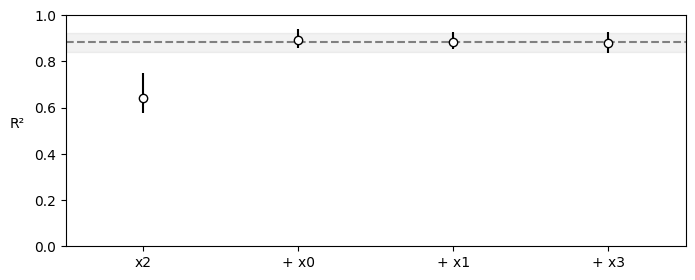

In [23]:
# Variable importance — columns 0 and 2 should account for all cumulative R2.
vi = pmb.compute_variable_importance(idata_bart, bartrv=mu, X=X_bart)
pmb.plot_variable_importance(vi);

## More building blocks

### Drop-in JAX with `pytensor.wrap_jax`

`pytensor.wrap_jax` makes any JAX-jittable function a first-class citizen in a PyMC model.
That means the whole JAX ecosystem (Equinox neural networks, Diffrax ODE solvers, Optax optimizers)
composes directly with your priors and likelihoods. Train a Bayesian neural network.
Put a prior on the parameters of an ODE. Mix and match.

In [24]:
import jax.numpy as jnp
from pytensor import wrap_jax

@wrap_jax
def forward(x, a, b):
    return jnp.tanh(a * x + b)

rng = np.random.default_rng(5)
x_wj = rng.normal(size=100)
y_wj = np.tanh(0.8 * x_wj + 0.1) + rng.normal(0, 0.1, size=100)

with pm.Model() as wrap_jax_model:
    a = pm.Normal("a")
    b = pm.Normal("b")
    mu_wj = forward(x_wj, a, b)
    pm.Normal("y", mu=mu_wj, observed=y_wj)

    idata_wj = pm.sample(backend="jax", progressbar="combined")

pm.stats.summary(idata_wj)

NUTS[nutpie]: [a, b]


Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b,0.131,0.148,-0.092,0.38,1959,1888,1.00,0.0035,0.0028
a,0.88,0.27,0.51,1.3,1824,1554,1.00,0.007,0.0068


Sampling still runs through nutpie — `backend="jax"` just tells PyMC to compile the model through the JAX path,
so the wrapped function stays native end-to-end.

### Automatic probability & `CustomDist`

Most PPLs let you define models by chaining random variables and derive the log-density automatically.
What's less known is that PyMC can also derive log-densities for transformations of existing distributions:
exponentiating, taking maxima, slicing — without you writing the math yourself. The list keeps growing!

Here we build a log-Student-T as exp of a Student-T, and ask PyMC for its log-density at 0.5

In [25]:
log_student_t = pm.math.exp(pm.StudentT.dist(nu=4, mu=0, sigma=1))

print(f"logp(LogStudentT, 0.5): {pm.logp(log_student_t, 0.5).eval():.4f}")

logp(LogStudentT, 0.5): -0.5713


The way to wire this into a model is with `pm.CustomDist`, which turns any `dist`-building
function into a first-class PyMC distribution:

In [26]:
def log_student_t_dist(nu, mu, sigma, size):
    return pm.math.exp(pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma, size=size))


with pm.Model() as m:
    mu = pm.Normal("mu")
    sigma = pm.HalfNormal("sigma")
    y = pm.CustomDist("y", 4.0, mu, sigma, dist=log_student_t_dist, observed=0.5)

m.point_logps(round_vals=4)["y"]

np.float64(-0.5713)

## Bayesian workflow

### ArviZ 1.0

PyMC v6 is compatible with the now grown up **ArviZ 1.0**.
Most of the changes are invisible to end users.
The objects you get back from `pm.sample` still resembles the good old `InferenceData`,
and the usual az.plot_* and az.summary calls keep working. But under the hood, a lot has changed.

**InferenceData → xarray.DataTree.** The InferenceData is replaced by xarray's new DataTree.
Arbitrary nesting is now allowed, I/O is more flexible (any format xarray supports is automatically available), and existing netCDF/Zarr files keep working.

**New plotting library.** arviz-plots ships with three backends at near-feature-parity: Matplotlib, Bokeh, and Plotly. Plots return a PlotCollection object built on grammar-of-graphics ideas, which makes faceting, aesthetic mappings, and custom compositions much cleaner. Browse some of the new plots at the [example gallery](https://python.arviz.org/projects/plots/en/latest/gallery/index.html).

**New default credible interval probability** has changed from 0.94 to 0.89, to remind everyone that no single number can rule us all. Perhaps more importantly, the default interval kind is now equal-tailed ("eti") rather than highest-density ("hdi"), and WAIC has been removed in favor of PSIS-LOO-CV for model comparison.

Oh and `plot_trace` is now `plot_trace_dist`...

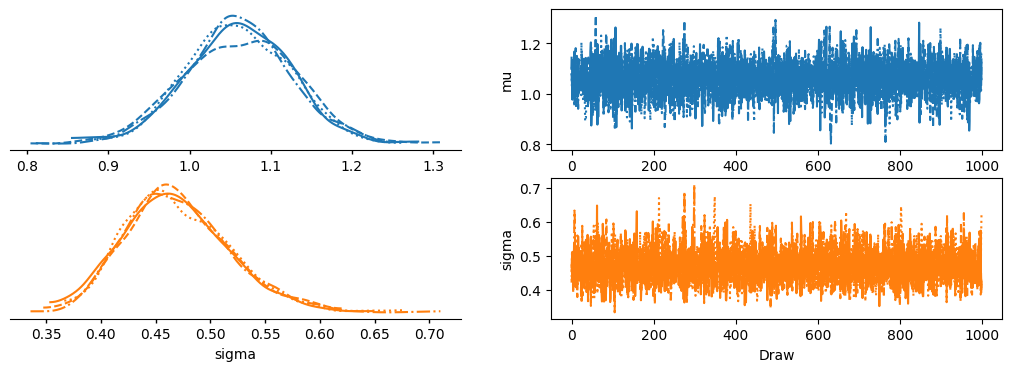

In [27]:
pm.plots.plot_trace_dist(idata_numba)

### PreliZ — prior elicitation

[PreliZ](https://preliz.readthedocs.io/) helps with one of the trickiest parts of the Bayesian workflow: prior choice.

Recent PreliZ work makes PyMC distributions and pymc-extras `Prior` objects first-class
citizens — `maxent`, matching, and plotting all accept them directly, and `from_pymc` /
`from_prior` convert them explicitly.

`maxent` also accepts any summary statistic (mean, variance, mode, …) as a fixed constraint,
and new `match_moments` / `match_quantiles` helpers build univariate distributions from moment or quantile targets.

The docs now ship a full [Distributions Gallery](https://preliz.readthedocs.io/en/latest/gallery/gallery.html).

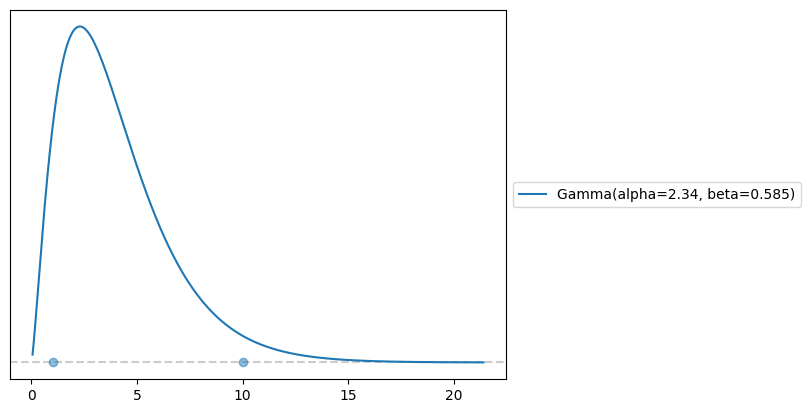

In [28]:
import preliz as pz

# "Find a Gamma with mass 0.9 between 1 and 10 — and pin the mean to 4."
(prior, _fig) = pz.maxent(pz.Gamma(), lower=1, upper=10, mass=0.90, fixed_stat=("mean", 4))

In [29]:
with pm.Model() as m:
    x = prior.to_pymc("x")
    idata = pm.sample(quiet=True)
pm.stats.summary(idata)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
x,3.9,2.6,0.85,8.8,1346,1456,1.00,0.064,0.078


### Kulprit — variable selection

[Kulprit](https://kulprit.readthedocs.io/) tackles a problem that shows up in almost
every real study: you measured many predictors, but the follow-up can only afford a
few. *Which ones?*

Kulprit takes a **Bambi** model containing all candidate variables and automatically
generates and ranks a set of plausible submodels with fewer variables using
[**projective predictive inference**](https://kulprit.readthedocs.io/en/latest/examples/Overview.html).
The projection is much faster than re-fitting every submodel, and more reliable than
LOO-based model comparison when the number of candidates is large.

In [30]:
# import bambi as bmb
# import kulprit as kpt
# import pandas as pd

# rng_k = np.random.default_rng(6)
# n_k, p_k = 200, 6
# X_k = pd.DataFrame(rng_k.normal(size=(n_k, p_k)), columns=[f"x{i}" for i in range(p_k)])
# # Only x0 and x2 are informative
# X_k["y"] = 0.5 + 1.5 * X_k["x0"] + 0.8 * X_k["x2"] + rng_k.normal(0, 0.3, n_k)

# full_model = bmb.Model("y ~ " + " + ".join(f"x{i}" for i in range(p_k)), X_k)
# idata_full = full_model.fit(chains=2, tune=200, draws=200, progressbar=False)

# ppi = kpt.ProjectionPredictive(full_model, idata_full)
# ppi.search()
# print(ppi)

## It has been a long ride

... something something